## Flight Price Prediction 

Data source: https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction

In [18]:
# Import the libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [3]:
# Load the data
df = pd.read_csv('archive/Clean_Dataset.csv')

# Print the data
print('Dataset loaded. Shape', df.shape)
print(df.head())

Dataset loaded. Shape (300153, 12)
   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning           Mumbai  Economy      2.17          1   5956  
3      Afternoon           Mumbai  Economy      2.25          1   5955  
4        Morning           Mumbai  Economy      2.33          1   5955  


In [4]:
df = df.drop('Unnamed: 0', axis=1)

In [5]:
df

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [6]:
# Handle categorical columns
label_encoder = {}

# Go through all of the columns that contain words/text
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoder[col] = le

In [7]:
# Features and Target
X = df.drop('price', axis=1)
y = df['price']

In [8]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

In [9]:
X_train

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left
148417,1,714,4,0,0,4,1,1,19.42,6
36879,3,110,2,0,1,5,1,1,7.00,13
274531,1,845,4,0,0,0,1,0,21.17,44
166397,5,1520,3,5,0,1,0,1,10.25,11
272722,5,1456,4,5,0,5,1,0,26.50,5
...,...,...,...,...,...,...,...,...,...,...
119879,5,1458,4,2,0,0,2,1,20.50,2
259178,5,1513,0,5,0,5,1,0,25.42,7
131932,1,846,4,5,0,4,5,1,13.67,29
146867,2,924,4,0,0,5,3,1,8.33,39


In [10]:
# Create and train the model

# Creating the model
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
# Predict the test values
predictions = model.predict(X_test)

In [19]:
# Evaluate the model
mse = mean_squared_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print('Models performance:')
print("MSE: ", mse)
print("r^2: ", r2)

Models performance:
MSE:  5342847.634788867
r^2:  0.9896352446849465


In [20]:
# Print the predictions (a sample)
comparison = pd.DataFrame(
    {
        "Actual Price": y_test.values[:20],
        "Predicted Price": predictions[:20]
    }
)

print("Sample Predictions:")
print(comparison)

Sample Predictions:
    Actual Price  Predicted Price
0           7366      7249.143333
1          64831     70922.306667
2           6195      6195.876667
3          60160     60340.320000
4           6578      6582.610000
5           4555      5581.073333
6          23838     23838.000000
7           3860      3857.366667
8          32230     33196.803333
9          76841     66279.950000
10         38099     38163.583333
11         60508     60508.000000
12          2477      2984.653333
13          7220      7536.846667
14         32859     32923.623333
15         20684     20684.000000
16          7212      7229.500000
17          7762      6570.636667
18         22140     22960.466667
19         10418     10375.776667


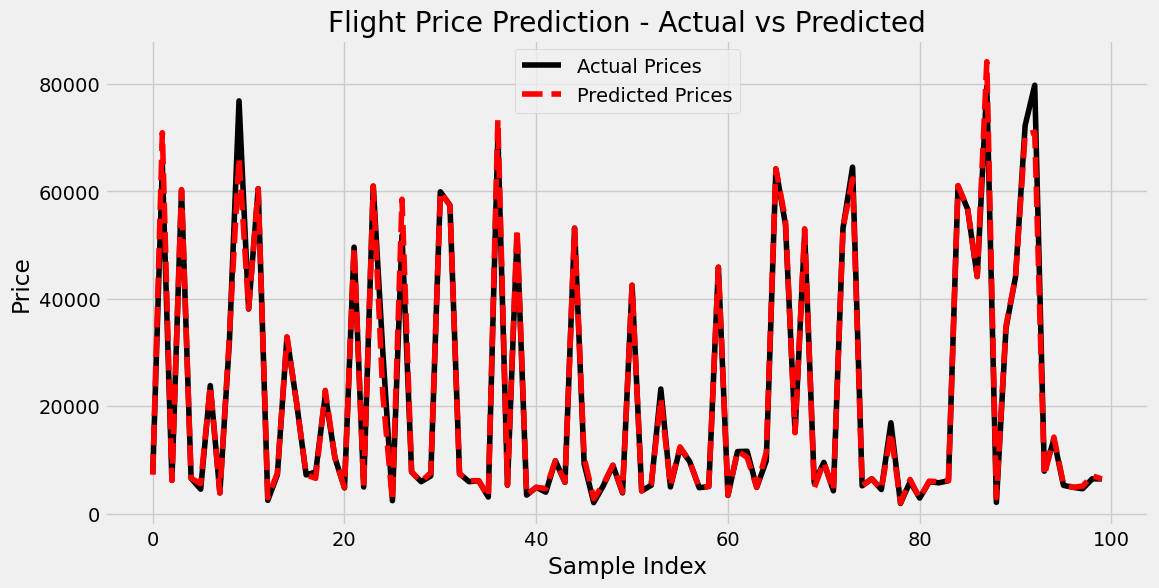

In [23]:
# Plot the actual values with the predicted values
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:100], label='Actual Prices', color='black')
plt.plot(predictions[:100], label='Predicted Prices', color='red', linestyle='--')
plt.title('Flight Price Prediction - Actual vs Predicted')
plt.xlabel('Sample Index')
plt.ylabel('Price')
plt.legend()
plt.show()